In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
df = pd.read_csv('Day15_Executive_Hotel_Booking_EDA_Dataset.csv')
df.head()

,Booking_ID,Hotel_Type,Hotel_Location,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,...,Meal_Type,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Reservation_Status,Is_Canceled,Reservation_Status_Date,Estimated_Revenue
0,HTL024548,City Hotel,London,2024-07-29,2025-07-04,340,2,2,2,0.0,...,HB,4,178.66,0,1,4.37,No-Show,1,2025-07-07,714.65
1,HTL019878,City Hotel,London,2024-05-28,2025-02-08,256,1,2,2,2.0,...,Undefined,3,125.81,0,0,3.63,Canceled,1,2025-02-09,377.43
2,HTL017377,City Hotel,Lisbon,2024-05-10,2024-06-20,41,1,1,4,0.0,...,FB,2,148.03,0,0,3.70,Check-Out,0,2024-06-20,296.06
3,HTL003352,City Hotel,Lisbon,2024-03-15,2024-04-07,23,0,2,2,0.0,...,HB,2,166.82,0,3,3.18,Check-Out,0,2024-04-08,333.63
4,HTL012521,City Hotel,London,2024-08-21,2025-05-30,282,0,3,4,0.0,...,HB,3,76.83,0,1,3.79,Check-Out,0,2025-06-01,230.50


In [2]:
print('Shape:', df.shape)
print(df.info())
quality = pd.DataFrame({'dtype':df.dtypes.astype(str),'missing':df.isna().sum(),'missing_pct':(df.isna().mean()*100).round(2),'unique':df.nunique()})
display(quality.sort_values('missing',ascending=False))
print('Duplicate rows:', df.duplicated().sum())
display(df.describe(include='all').T)

Shape: (25180, 35)
<class 'pandas.DataFrame'>
RangeIndex: 25180 entries, 0 to 25179
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Booking_ID                   25180 non-null  str    
 1   Hotel_Type                   25180 non-null  str    
 2   Hotel_Location               25074 non-null  str    
 3   Booking_Date                 25180 non-null  str    
 4   Arrival_Date                 25180 non-null  str    
 5   Lead_Time_Days               25180 non-null  int64  
 6   Weekend_Nights               25180 non-null  int64  
 7   Weekday_Nights               25180 non-null  int64  
 8   Adults                       25180 non-null  int64  
 9   Children                     25059 non-null  float64
 10  Babies                       25180 non-null  int64  
 11  Country                      24714 non-null  str    
 12  Market_Segment               25180 non-null  str    
 13  Distribu

,dtype,missing,missing_pct,unique
Company_ID,float64,20729,82.32,119
Country,str,466,1.85,24
Agent_ID,float64,304,1.21,179
Meal_Type,str,245,0.97,9
Satisfaction_Score,float64,164,0.65,276
Children,float64,121,0.48,5
Hotel_Location,str,106,0.42,11
ADR,float64,82,0.33,13269
Booking_ID,str,0,0.00,25000
Hotel_Type,str,0,0.00,5


Duplicate rows: 180


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Booking_ID,25180,25000,HTL000016,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hotel_Type,25180,5,City Hotel,15606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hotel_Location,25074,11,Dubai,3171,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Booking_Date,25180,731,2025-12-10,58,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Arrival_Date,25180,1073,2026-01-02,54,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lead_Time_Days,25180.0,NaN,NaN,NaN,182.200556,105.604452,0.0,91.0,182.0,273.0,920.0
Weekend_Nights,25180.0,NaN,NaN,NaN,1.240429,1.063802,0.0,0.0,1.0,2.0,3.0
Weekday_Nights,25180.0,NaN,NaN,NaN,2.451072,2.031003,0.0,1.0,2.0,4.0,13.0
Adults,25180.0,NaN,NaN,NaN,2.198967,0.662379,1.0,2.0,2.0,2.0,7.0
Children,25059.0,NaN,NaN,NaN,0.372122,0.657811,0.0,0.0,0.0,1.0,6.0


In [3]:
df=df.copy(); df.columns=df.columns.str.strip()
for c in ['Booking_Date','Arrival_Date','Reservation_Status_Date']: df[c]=pd.to_datetime(df[c],errors='coerce')
text_cols=['Hotel_Type','Hotel_Location','Country','Market_Segment','Distribution_Channel','Room_Type_Reserved','Room_Type_Assigned','Deposit_Type','Customer_Type','Meal_Type','Reservation_Status']
for c in text_cols: df[c]=df[c].astype('string').str.strip()
for c in ['Hotel_Type','Market_Segment','Distribution_Channel','Deposit_Type','Customer_Type','Meal_Type']: df[c]=df[c].str.title()
for c in ['Country','Hotel_Location','Meal_Type']: df[c]=df[c].fillna('Unknown')
for c in ['Children','Agent_ID','Company_ID']: df[c]=df[c].fillna(0)
for c in ['ADR','Satisfaction_Score']: df[c]=df[c].fillna(df[c].median())
df=df.drop_duplicates().copy()
df['Total_Guests']=df.Adults+df.Children+df.Babies
df['Arrival_Month']=df.Arrival_Date.dt.month_name()
df['Lead_Time_Band']=pd.cut(df.Lead_Time_Days,[-1,7,30,90,180,np.inf],labels=['0-7','8-30','31-90','91-180','181+'])
print(df.shape)

(25000, 38)


In [4]:
num=df.select_dtypes(include=np.number).columns
q1=df[num].quantile(.25); q3=df[num].quantile(.75); iqr=q3-q1
out=((df[num]<(q1-1.5*iqr))|(df[num]>(q3+1.5*iqr))).sum().sort_values(ascending=False)
display(out[out>0].head(15))

Adults                         7529
Required_Car_Parking_Spaces    4543
Company_ID                     4415
Is_Repeated_Guest              4322
Previous_Bookings              4322
Days_In_Waiting_List           4082
Booking_Changes                1279
Total_Guests                   1082
Babies                          959
Previous_Cancellations          687
Estimated_Revenue               652
ADR                             360
Satisfaction_Score              282
Children                        210
Weekday_Nights                  143
dtype: int64

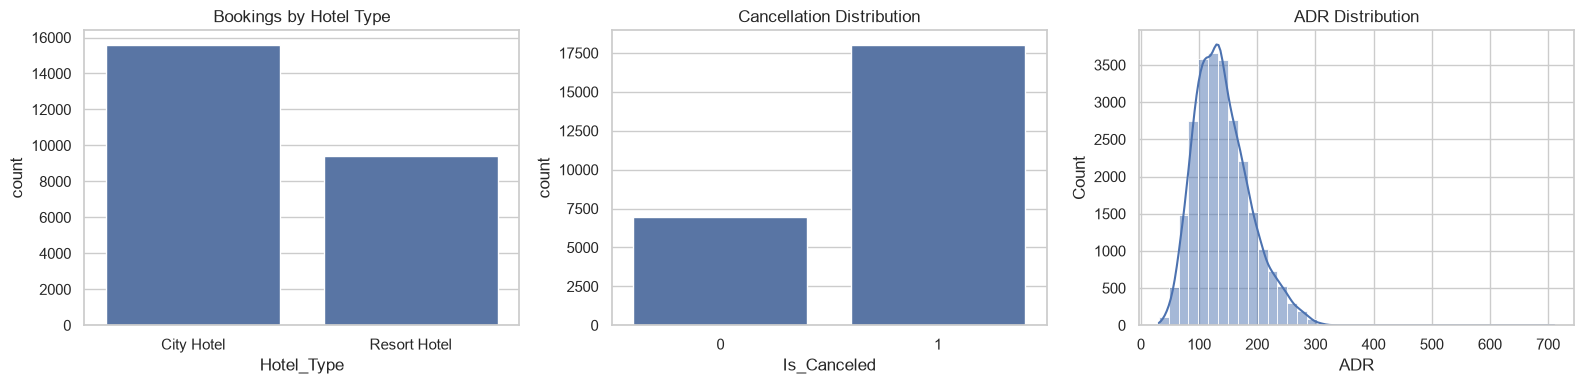

In [5]:
fig,ax=plt.subplots(1,3,figsize=(16,4))
sns.countplot(data=df,x='Hotel_Type',ax=ax[0]); ax[0].set_title('Bookings by Hotel Type')
sns.countplot(data=df,x='Is_Canceled',ax=ax[1]); ax[1].set_title('Cancellation Distribution')
sns.histplot(data=df,x='ADR',bins=40,kde=True,ax=ax[2]); ax[2].set_title('ADR Distribution')
plt.tight_layout(); plt.show()

,Bookings,Cancellation_Rate,Average_ADR,Revenue
Hotel_Type,,,,
City Hotel,15611,73.30,120.76,6018324.50
Resort Hotel,9389,70.31,173.56,7365874.95


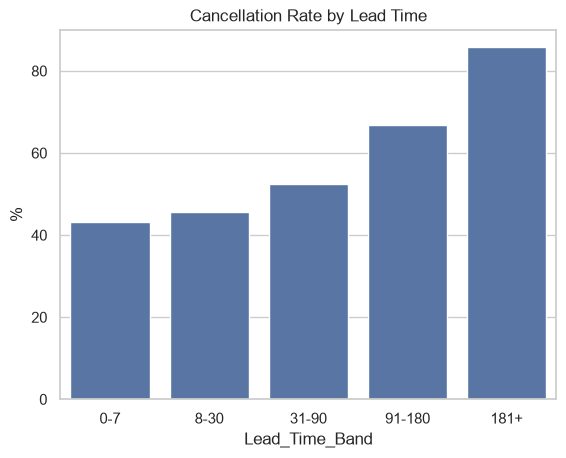

,Bookings,Cancellation_Rate,Revenue
Market_Segment,,,
Online Ta,10852,75.10,5932008.25
Offline Ta/To,5440,70.42,2944293.73
Direct,3808,71.22,2098049.99
Corporate,2990,67.49,1492611.61
Groups,1910,69.79,917235.87


In [6]:
hotel=df.groupby('Hotel_Type').agg(Bookings=('Booking_ID','count'),Cancellation_Rate=('Is_Canceled','mean'),Average_ADR=('ADR','mean'),Revenue=('Estimated_Revenue','sum'))
hotel['Cancellation_Rate']*=100
display(hotel.round(2))
lead=df.groupby('Lead_Time_Band',observed=False).agg(Bookings=('Booking_ID','count'),Cancellation_Rate=('Is_Canceled','mean')).reset_index(); lead.Cancellation_Rate*=100
sns.barplot(data=lead,x='Lead_Time_Band',y='Cancellation_Rate'); plt.title('Cancellation Rate by Lead Time'); plt.ylabel('%'); plt.show()
segment=df.groupby('Market_Segment').agg(Bookings=('Booking_ID','count'),Cancellation_Rate=('Is_Canceled','mean'),Revenue=('Estimated_Revenue','sum')).sort_values('Bookings',ascending=False); segment.Cancellation_Rate*=100; display(segment.head(10).round(2))

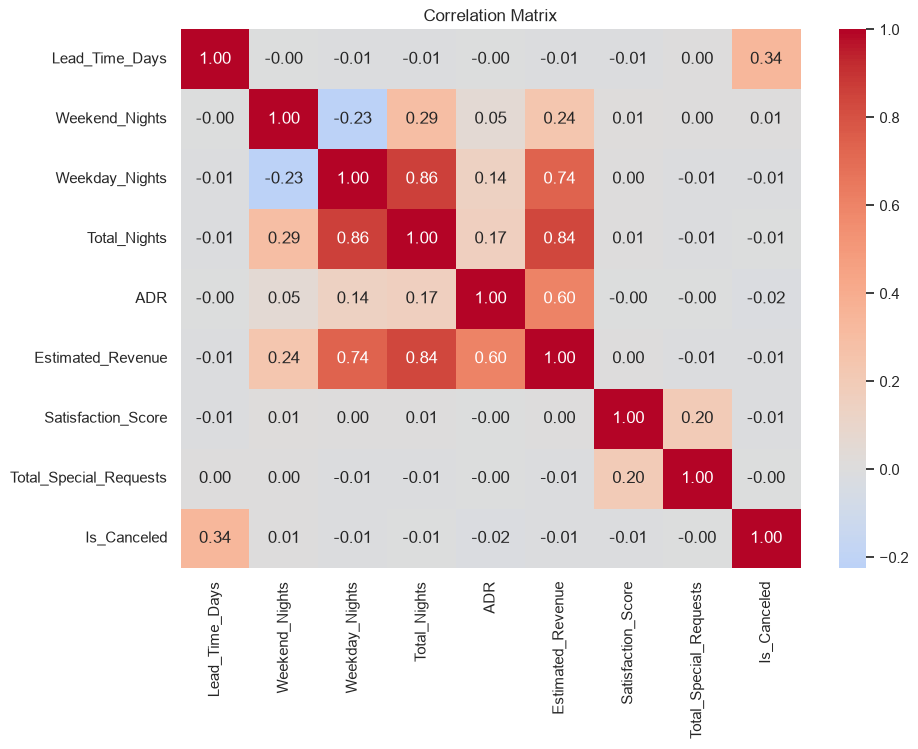

Is_Canceled               1.000000
Lead_Time_Days            0.343847
Weekend_Nights            0.005836
Total_Special_Requests   -0.003466
Total_Nights             -0.005056
Weekday_Nights           -0.006982
Satisfaction_Score       -0.010438
Estimated_Revenue        -0.013002
ADR                      -0.017025
Name: Is_Canceled, dtype: float64

In [7]:
cols=['Lead_Time_Days','Weekend_Nights','Weekday_Nights','Total_Nights','ADR','Estimated_Revenue','Satisfaction_Score','Total_Special_Requests','Is_Canceled']
corr=df[cols].corr()
plt.figure(figsize=(10,7)); sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm',center=0); plt.title('Correlation Matrix'); plt.show()
display(corr['Is_Canceled'].sort_values(ascending=False))

In [ ]:
Create a cancellation-risk dashboard using lead time, segment, channel, and deposit type.

Offer targeted commitment incentives for long-lead bookings.

Review and A/B test deposit policies by customer segment.

Prioritize high-value Resort Hotel demand and optimize City Hotel pricing.

Use cancellation forecasts for inventory allocation and carefully controlled overbooking.

Shift marketing spend toward segments/channels with stronger realized revenue and lower cancellation risk.

Track cancellations, ADR, revenue, and monthly demand in a recurring executive dashboard.